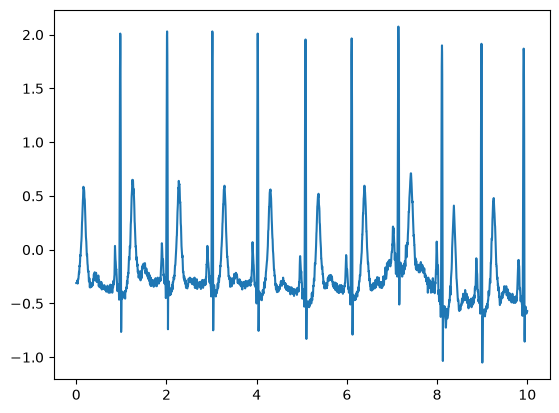

In [ ]:
#Cómo introducción, el proceso de Pan-Tompkins es un algoritmo para la detección de picos R en señales de ECG. 
#Este algoritmo se basa en la idea de que los picos R son los puntos más altos de la señal de ECG, y por lo tanto,
#se pueden detectar mediante un proceso de filtrado y umbralización.

#Este proceso implica algunos pasos:
#1.-Obtener la tasa de crecimiento, ya que sabiendo que los picos R son los puntos más altos de la señal,
#Podemos obtener la tasa de crecimiento de la señal, y así obtener los picos R.
#2.-Elevar todo al cuadrado, de esta manera, los picos R serán los puntos más altos de la señal, y los picos negativos serán los puntos más bajos de la señal.
#3.-Aplicar un filtro de media móvil, de esta manera, los picos R serán los puntos más altos de la señal, y los picos negativos serán los puntos más bajos 
#4.-Buscar los picos R en la señal ya suavizada

import wfdb;
import numpy as np;
import matplotlib.pyplot as plt;
from scipy.signal import find_peaks;

record = wfdb.rdrecord('../data/mitdb/106')
time = np.arange(0, 10 * record.fs) / record.fs
seg = record.p_signal[:10 * record.fs, 0] 
plt.plot(time, seg)

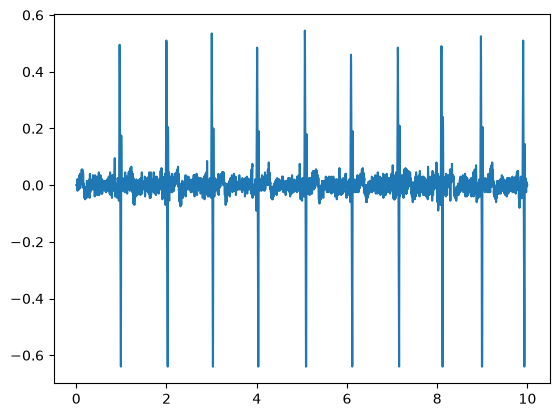

In [8]:
#Ahora, que obtuvimos la señal, debemos encontrar su "derivada" o tasa de crecimiento, para esto, podemos usar la función np.diff
derivada = np.diff(seg)
plt.plot(time[:-1], derivada)

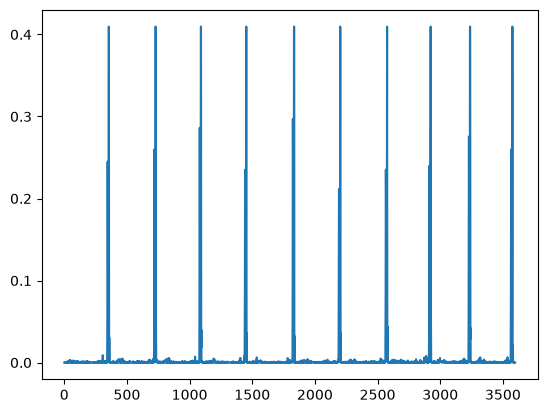

In [9]:
#Ahora, debemos elevar todo al cuadrado, de esta manera, los picos R serán los puntos más altos de la señal, y los picos negativos serán los puntos más bajos de la señal.
record_squared = derivada ** 2
plt.plot(record_squared)

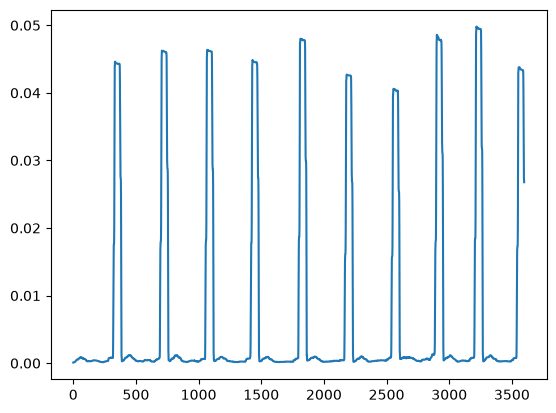

In [42]:
#Ahora, aplicaremos la convolución, de este modo, podremos suavizar la señal, y así poder encontrar los picos R. 
#Para esto, podemos usar la función np.convolve, y un filtro de media móvil de 150 ms.

convolution_window = int(0.150 * record.fs)  # 150 ms
window = np.ones(convolution_window) / convolution_window
convolv = np.convolve(record_squared, window, mode='same')
plt.plot(convolv)

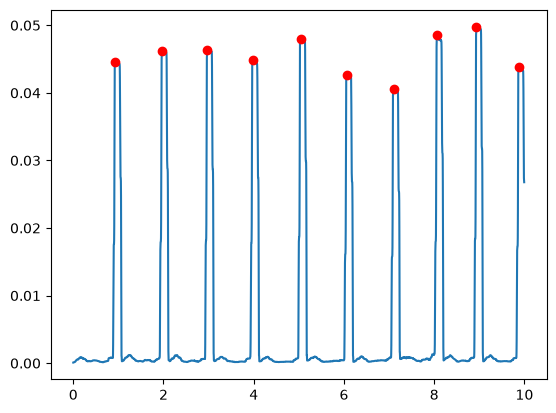

In [43]:
#Aquí vemos que la señal ya está suavizada, y podemos ver los picos R, pero aún no hemos encontrado los picos R
#Ahora, debemos buscar los picos R en la señal ya suavizada, para esto, podemos usar la función find_peaks de scipy.signal.find_peaks, y un umbral de 0.5
umbral = 0.3 * convolv.max()
picos = find_peaks(convolv, height = umbral, distance = int(0.25 * record.fs))[0]
plt.plot(time[:-1], convolv)
plt.plot(time[picos], convolv[picos], 'ro')

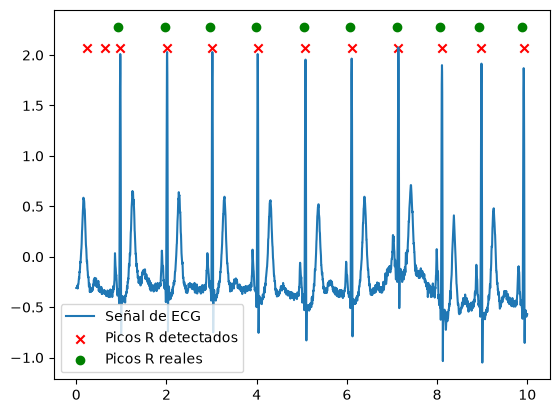

In [27]:
#Ahora, podemos comprobar con las anotaciones del registro, para esto, podemos usar la función rdann de wfdb, y el archivo de anotaciones correspondiente al registro.
annotations = wfdb.rdann('../data/mitdb/106', 'atr')
picos_reales = annotations.sample[annotations.sample < 10 * record.fs]
tiempos_detectados = time[:-1][picos]
tiempos_reales = picos_reales / record.fs
plt.Figure(figsize=(15, 5))
plt.plot(time, seg)
plt.scatter(tiempos_reales, [seg.max()] * len(tiempos_reales), marker='x', color='r')
plt.scatter(tiempos_detectados, [seg.max() * 1.1] * len(tiempos_detectados), marker='o', color='g')
plt.legend(['Señal de ECG', 'Picos R detectados', 'Picos R reales'])
plt.show()

In [54]:
#"El detector simplificado alcanza una detección visualmente correcta en la mayoría de los latidos, pero presenta:
#(1) un falso positivo por detección duplicada cuando dos picos caen muy cerca entre sí
#(2) posibles falsos negativos en los bordes de la ventana de análisis, donde el algoritmo no cuenta con suficiente contexto temporal."
